# GSGP-NN: Test Suite Execution & Regression Demo

This notebook provides a complete environment to:
1. **Execute all the unit & integration tests** in the project using `pytest`.
2. **Train a Geometric Semantic Genetic Programming Neural Network (GSGP-NN)** on a scikit-learn regression dataset (the Diabetes dataset) and evaluate its performance.

## 1. Execute Project Tests

In [7]:
import sys
import os
import pytest

# Ensure project root is in python path so that 'src' can be imported
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Running pytest on the 'tests' directory...")
exit_code = pytest.main(["-v", "../tests"])
print(f"Pytest finished with exit code: {exit_code} (0 means all tests passed)")

Running pytest on the 'tests' directory...
============================= test session starts ==============================
platform linux -- Python 3.10.20, pytest-9.1.1, pluggy-1.6.0 -- /home/gallobota/miniconda3/envs/gsgp_nn/bin/python
cachedir: .pytest_cache
rootdir: /home/gallobota/GSGP_NN
plugins: anyio-4.12.1
collecting ... collected 33 items

../tests/test_evolution.py::TestGPNode::test_terminal_constant PASSED    [  3%]
../tests/test_evolution.py::TestGPNode::test_terminal_variable PASSED    [  6%]
../tests/test_evolution.py::TestGPNode::test_terminal_missing_variable PASSED [  9%]
../tests/test_evolution.py::TestGPNode::test_addition PASSED             [ 12%]
../tests/test_evolution.py::TestGPNode::test_subtraction PASSED          [ 15%]
../tests/test_evolution.py::TestGPNode::test_multiplication PASSED       [ 18%]
../tests/test_evolution.py::TestGPNode::test_protected_division_normal PASSED [ 21%]
../tests/test_evolution.py::TestGPNode::test_protected_division_by_zero PASSE

## 2. Regression Demo with Scikit-Learn Dataset

In [9]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from src.data.loader import prepare_semantic_data
from src.models.gsgp_nn import GSGPNN
from src.training.trainer import Trainer
from src.training.early_stopping import EarlyStopping
from src.utils.device import get_device
from src.utils.seed import set_seed

# Set seeds for reproducibility
set_seed(42)
# Determine execution device (CPU or GPU/CUDA)
device = get_device()
print(f"Using device: {device}")

[Device] Using GPU: NVIDIA GeForce GTX 1650
[Device] VRAM: 4.3 GB
[Device] CUDA Capability: 7.5
Using device: cuda


### Load and Prepare Data
We load the scikit-learn Diabetes dataset (a classic regression task), scale the features and target to aid neural network optimization, and split into train/test sets.

In [10]:
X, y = load_diabetes(return_X_y=True)
print(f"Dataset features shape: {X.shape}")
print(f"Dataset target shape: {y.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize targets
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Convert targets to PyTorch tensors on target device
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32, device=device)

Dataset features shape: (442, 10)
Dataset target shape: (442,)


### GP Populations & Semantics Preparation
We use the helper function `prepare_semantic_data` to generate GP populations and compute the initial, parent, and route semantics for training. Then, we construct the corresponding semantic tensors for testing.

In [11]:
num_nodes = 10
num_layers = 3
pop_size = 40

# Prepare training semantic data
print("Generating GP trees and evaluating train semantics...")
train_data = prepare_semantic_data(
    X=X_train_scaled,
    num_nodes=num_nodes,
    num_layers=num_layers,
    population_size=pop_size,
    device=device
)

# Evaluate the same GP trees on the test dataset to get test semantics
print("Evaluating test semantics...")
evaluator = train_data["evaluator"]
initial_matrix_test = evaluator.create_semantic_matrix(train_data["initial_population"], X_test_scaled)
auxiliary_matrix_test = evaluator.create_semantic_matrix(train_data["auxiliary_population"], X_test_scaled)

# Construct initial semantics for test set
combined_matrix_test = torch.cat([initial_matrix_test, auxiliary_matrix_test], dim=0)
init_rows_test = [combined_matrix_test[n % combined_matrix_test.shape[0]] for n in range(num_nodes)]
initial_semantics_test = torch.stack(init_rows_test, dim=0)

# Construct parent semantics for test set
parent_rows_test = [initial_matrix_test[n % initial_matrix_test.shape[0]] for n in range(num_nodes)]
parent_semantics_test = torch.stack(parent_rows_test, dim=0)

# Construct route semantics for test set
route_semantics_test = []
aux_idx = 0
for k in range(num_layers):
    rt1_rows = []
    rt2_rows = []
    for n in range(num_nodes):
        rt1_idx = aux_idx % auxiliary_matrix_test.shape[0]
        rt1_rows.append(auxiliary_matrix_test[rt1_idx])
        aux_idx += 1
        
        rt2_idx = aux_idx % auxiliary_matrix_test.shape[0]
        rt2_rows.append(auxiliary_matrix_test[rt2_idx])
        aux_idx += 1
        
    route_semantics_test.append({
        "rt1": torch.stack(rt1_rows, dim=0),
        "rt2": torch.stack(rt2_rows, dim=0)
    })

test_data = {
    "initial_semantics": initial_semantics_test,
    "parent_semantics": parent_semantics_test,
    "route_semantics": route_semantics_test
}
print("Train and test semantic data successfully prepared!")

Generating GP trees and evaluating train semantics...
[GP] Generating populations of size 40...
[GP] Evaluating initial population semantics...
[GP] Evaluating auxiliary population semantics...
[GP] Semantic tensors ready — initial: torch.Size([10, 353]), parent: torch.Size([10, 353]), routes: 3 layers × (N=10, M=353)
Evaluating test semantics...
Train and test semantic data successfully prepared!


### Initialize and Train the GSGP-NN Model

In [12]:
# Define model
model = GSGPNN(num_nodes=num_nodes, num_layers=num_layers).to(device)
print(model.summary())

# Define early stopping
early_stopping = EarlyStopping(patience=20, min_delta=1e-5, warmup_epochs=10)

# Train model using Trainer
trainer = Trainer(
    model=model,
    learning_rate=0.01,
    early_stopping=early_stopping
)

history = trainer.fit(
    semantic_data=train_data,
    y_train=y_train_tensor,
    epochs=200
)

GSGPNN(N=10, K=3)
  Trainable parameters: 401
  Layers:
    [0] GSGPNNLayer — alpha: (11, 10), ms: (10,), beta: (10,)
    [1] GSGPNNLayer — alpha: (11, 10), ms: (10,), beta: (10,)
    [2] GSGPNNLayer — alpha: (11, 10), ms: (10,), beta: (10,)
    [out] Linear — weight: (1, 10), bias: (1,)
Epoch    1: Loss = 0.965656   [1782976865.678s]
Epoch    2: Loss = 0.943062   [1782976865.689s]
Epoch    3: Loss = 0.920643   [1782976865.700s]
Epoch    4: Loss = 0.898162   [1782976865.711s]
Epoch    5: Loss = 0.875099   [1782976865.734s]
Epoch    6: Loss = 0.851445   [1782976865.747s]
Epoch    7: Loss = 0.827543   [1782976865.760s]
Epoch    8: Loss = 0.803593   [1782976865.773s]
Epoch    9: Loss = 0.780201   [1782976865.789s]
Epoch   10: Loss = 0.757907   [1782976865.806s]
Epoch   11: Loss = 0.737377   [1782976865.819s]
Epoch   12: Loss = 0.719194   [1782976865.831s]
Epoch   13: Loss = 0.703617   [1782976865.844s]
Epoch   14: Loss = 0.690646   [1782976865.861s]
Epoch   15: Loss = 0.679669   [17829768

### Model Evaluation
Let's visualize the loss history, calculate metrics (MSE, R²) on the test set, and plot actual vs predicted values.

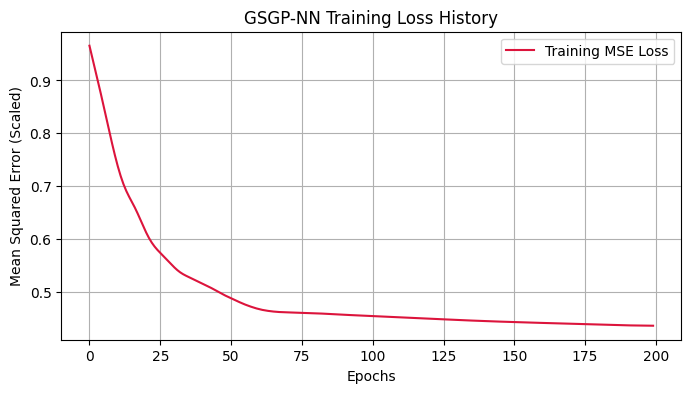

Test Mean Squared Error (MSE): 3337.5830
Test R2 Score: 0.3700


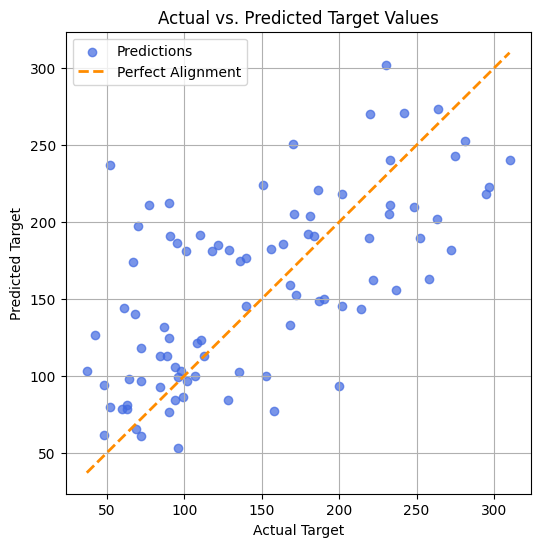

In [13]:
# Plot Loss curve
plt.figure(figsize=(8, 4))
plt.plot(history["loss_history"], label="Training MSE Loss", color="crimson")
plt.title("GSGP-NN Training Loss History")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (Scaled)")
plt.legend()
plt.grid(True)
plt.show()

# Run inference on test data
y_pred_scaled = trainer.predict(test_data).cpu().numpy()

# Inverse scale targets/predictions back to original space
y_test_original = y_test
y_pred_original = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# Compute metrics
mse = mean_squared_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)
print(f"Test Mean Squared Error (MSE): {mse:.4f}")
print(f"Test R2 Score: {r2:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test_original, y_pred_original, color="royalblue", alpha=0.7, label="Predictions")
plt.plot([min(y_test_original), max(y_test_original)], [min(y_test_original), max(y_test_original)], 
         color="darkorange", linestyle="--", linewidth=2, label="Perfect Alignment")
plt.title("Actual vs. Predicted Target Values")
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.legend()
plt.grid(True)
plt.show()